# Assignment 5 - Out-Of-Sample Long-Only Mean Reversion


## Research Objective And Frozen Design

The idea notebook selected a volatility-scaled weekly reversal score during the 2010-2019 development period. This notebook keeps that signal frozen and evaluates it out of sample from January 2020 onward, using only information available at each rebalance date.

The analysis compares two long-only implementation layers:

1. **direct EWMA strategies**, where the score rule maps eligible stocks into holdings and EWMA smoothing controls turnover;
2. **Black-Litterman strategies**, where the same signal baskets become prior-relative views solved through the professor optimization framework.

The benchmark is SPI. The main comparison is economic: gross performance, net performance after 20 bps variable transaction costs and a 1% annual fee, turnover, drawdowns, win rate and factor-adjusted alpha.


## Configuration, Data And Frozen Score

The configuration cell records the frozen research choices used in the out-of-sample test: signal construction, tradability filters, EWMA parameters, Black-Litterman view calibration, transaction costs and reporting assumptions. Keeping these assumptions in one place makes the backtest auditable and avoids re-tuning on the 2020+ evaluation period.


In [1]:
import importlib
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

pd.options.display.float_format = "{:,.4f}".format

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").is_dir() or not (PROJECT_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository root or assignments folder.")

SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helper_functions import load_data_spi, load_jkp_factor_series
from backtesting.backtest import Backtest
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest_item_builder.bib_classes import OptimizationItemBuilder, SelectionItemBuilder
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_cap_weights,
    bibfn_return_series,
    bibfn_scores,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_box_constraints,
    bibfn_budget_constraint,
    bibfn_turnover_constraint,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_gaps,
    bibfn_selection_jkp_data_scores,
    bibfn_selection_min_volume,
)
from backtesting.portfolio import Portfolio
from estimation.black_litterman import bl_posterior_mu_sigma
from optimization.optimization import Objective, Optimization
import backtesting.backtest as backtest_module
import backtesting.backtest_service as backtest_service_module
import backtesting.strategy as strategy_module

# Reload local framework modules so an already-open notebook kernel picks up
# the patched professor Strategy.simulate implementation consistently.
strategy_module = importlib.reload(strategy_module)
backtest_module = importlib.reload(backtest_module)
backtest_service_module = importlib.reload(backtest_service_module)
Strategy = strategy_module.Strategy
Backtest = backtest_module.Backtest
BacktestService = backtest_service_module.BacktestService


In [2]:
@dataclass(frozen=True)
class StrategyConfig:
    """Frozen assumptions for the out-of-sample long-only implementation."""

    # 1. Execution switches
    run_ewma_strategies: bool = True
    run_black_litterman_strategies: bool = True

    # 2. Out-of-sample window and weekly signal timing
    start_date: str = "2020-01-01"
    end_date: Optional[str] = None
    weekly_resample_rule: str = "W-FRI"
    weekly_min_days: int = 3
    score_lag_weeks: int = 0

    # 3. Frozen volatility-scaled reversal score
    score_field: str = "vol_scaled_reversal"
    vol_lookback_weeks: int = 104
    min_vol_weeks: int = 26

    # 4. Professor-framework tradability filters
    # Liquidity is daily traded monetary value. These values match the code.
    min_median_daily_traded_value: float = 100_000
    volume_window_days: int = 63
    max_zero_volume_gap_days: int = 10
    lookback_days: int = 365

    # 5. Direct long-only implementation choices
    tail_fraction: float = 0.10
    # EWMA adjustment speeds are frozen from the idea-notebook SR maximization
    # on the tradable-universe long contribution of each strategy.
    continuous_ewma_lambda: float = 0.50
    tail_ewma_lambda: float = 0.30
    long_only_gross_exposure: float = 1.00
    # Drop tiny EWMA residual positions before renormalizing.
    min_active_weight: float = 0.001

    # 6. Implementation-cost assumptions
    transaction_cost_bps: int = 20
    fixed_cost_annual: float = 0.01
    show_backtest_progress: bool = True
    trading_days_per_year: int = 252
    rebalances_per_year: int = 52

    # 7. Factor-model benchmark
    factor_names: tuple[str, ...] = ("size", "value", "momentum")
    factor_hac_lags: int = 5

    # 8. Black-Litterman signal-tilted implementation
    # View returns and variances are weekly values frozen from the 2010-2019 idea notebook.
    # Turnover penalty is a tunable one-way cost rate; 0.002 corresponds to 20 bps.
    bl_turnover_penalty: float = 0.002
    # The hard turnover cap is an optional safety constraint, disabled by default.
    bl_use_hard_turnover_cap: bool = False
    bl_turnover_limit: float = 0.30
    bl_stock_upper_bound: float = 0.10
    bl_tau: float = 0.05
    bl_risk_aversion: float = 2.50
    bl_continuous_view_return: float = 0.0023
    bl_continuous_view_variance: float = 0.0008
    bl_tail_view_return: float = 0.0048
    bl_tail_view_variance: float = 0.0020

    # 9. Data locations
    data_dir: Path = DATA_DIR
    results_dir: Path = RESULTS_DIR
    score_path: Path = RESULTS_DIR / "mean_reversion_vol_scaled_scores_oos.parquet"


CONFIG = StrategyConfig()
TC_RATE = CONFIG.transaction_cost_bps / 10_000
CONFIG


StrategyConfig(run_ewma_strategies=True, run_black_litterman_strategies=True, start_date='2020-01-01', end_date=None, weekly_resample_rule='W-FRI', weekly_min_days=3, score_lag_weeks=0, score_field='vol_scaled_reversal', vol_lookback_weeks=104, min_vol_weeks=26, min_median_daily_traded_value=100000, volume_window_days=63, max_zero_volume_gap_days=10, lookback_days=365, tail_fraction=0.1, continuous_ewma_lambda=0.5, tail_ewma_lambda=0.3, long_only_gross_exposure=1.0, min_active_weight=0.001, transaction_cost_bps=20, fixed_cost_annual=0.01, show_backtest_progress=True, trading_days_per_year=252, rebalances_per_year=52, factor_names=('size', 'value', 'momentum'), factor_hac_lags=5, bl_turnover_penalty=0.002, bl_use_hard_turnover_cap=False, bl_turnover_limit=0.3, bl_stock_upper_bound=0.1, bl_tau=0.05, bl_risk_aversion=2.5, bl_continuous_view_return=0.0023, bl_continuous_view_variance=0.0008, bl_tail_view_return=0.0048, bl_tail_view_variance=0.002, data_dir=WindowsPath('C:/Users/axeli/Deskt

## Strategy Class Design

The notebook uses the professor framework according to the economic role of each method.

- The EWMA strategies are deterministic `Strategy` subclasses. Once the eligible score vector is known, the notebook builds target weights, applies EWMA smoothing, removes ineligible names and stores the result as dated professor `Portfolio` objects.
- The Black-Litterman strategy is an `Optimization` subclass. The signal basket defines a view, while `BacktestService` supplies the selected universe, trailing returns, benchmark weights, constraints and previous holdings at each rebalance.
- Performance is evaluated consistently after portfolios are built. All strategies use professor `Strategy.simulate()` for gross and net returns and `Strategy.turnover()` for traded notional.

This split keeps the implementation close to the research logic while avoiding unnecessary custom backtesting code.


## EWMA Strategy Classes

The EWMA strategies translate the frozen reversal score directly into long-only portfolios. The shared base class handles the common implementation mechanics: target construction, EWMA smoothing, eligibility cuts, dust-position removal, renormalization and conversion into professor `Portfolio` objects.

The smoothing rule is:

$$
w^{EWMA}_t = \lambda w^{target}_t + (1-\lambda)w^{EWMA}_{t-1}.
$$

Two target rules are tested:

- **continuous rank-weighted**: hold stocks above the cross-sectional median, with weights proportional to positive centered ranks;
- **top-tail equal-weighted**: hold the highest-score 10% of eligible stocks with equal weights.

Both use only point-in-time eligible scores. Stocks that fail the professor tradability filters at a rebalance are removed before the portfolio is renormalized.


In [3]:
class BaseEWMAStrategy(Strategy):
    """Shared EWMA implementation for deterministic long-only signal rules."""

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.eligible_scores = {
            pd.Timestamp(date): scores.dropna().sort_index()
            for date, scores in eligible_scores.items()
        }
        self.lambda_value = lambda_value
        self.gross_exposure = gross_exposure
        self.min_active_weight = min_active_weight

        # Target weights are built from the frozen signal only. EWMA is applied
        # afterward to reduce turnover without changing the signal definition.
        self.target_weights = self._build_target_weights()
        self.weights = self._smooth_target_weights()
        super().__init__(self._to_portfolios(self.weights))

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        raise NotImplementedError

    def _build_target_weights(self) -> pd.DataFrame:
        rows = {}
        for date, scores in self.eligible_scores.items():
            target = self._raw_target(scores)
            if target.sum() > 0:
                rows[date] = self.gross_exposure * target / target.sum()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    def _smooth_target_weights(self) -> pd.DataFrame:
        state = pd.Series(0.0, index=self.target_weights.columns)
        rows = {}
        for date, target in self.target_weights.iterrows():
            eligible = pd.Index(self.eligible_scores[date].index)
            state = (1 - self.lambda_value) * state + self.lambda_value * target

            # Do not carry stale or immaterial positions into the next rebalance.
            state.loc[~state.index.isin(eligible)] = 0.0
            state.loc[state < self.min_active_weight] = 0.0

            if state.sum() > 0:
                state = self.gross_exposure * state / state.sum()
                rows[date] = state.copy()
        return pd.DataFrame(rows).T.sort_index().fillna(0.0)

    @staticmethod
    def _to_portfolios(weights: pd.DataFrame) -> list[Portfolio]:
        return [
            Portfolio(
                rebalancing_date=date.strftime("%Y-%m-%d"),
                weights=row[row.abs() > 0],
            )
            for date, row in weights.iterrows()
        ]


class ContinuousRankEWMAStrategy(BaseEWMAStrategy):
    """Long-only EWMA strategy using positive centered ranks."""

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        if len(scores) < 2 or scores.nunique() < 2:
            return pd.Series(dtype=float)

        ranks = scores.rank(method="average")
        centered_rank = 2 * (ranks - 1) / (len(scores) - 1) - 1
        return centered_rank.clip(lower=0.0)


In [4]:
class TopTailEWMAStrategy(BaseEWMAStrategy):
    """Long-only EWMA strategy holding the highest-score tail equally."""

    def __init__(
        self,
        eligible_scores: dict[pd.Timestamp, pd.Series],
        tail_fraction: float,
        lambda_value: float,
        gross_exposure: float = 1.0,
        min_active_weight: float = 0.001,
    ):
        self.tail_fraction = tail_fraction
        super().__init__(
            eligible_scores=eligible_scores,
            lambda_value=lambda_value,
            gross_exposure=gross_exposure,
            min_active_weight=min_active_weight,
        )

    def _raw_target(self, scores: pd.Series) -> pd.Series:
        n_tail = int(np.floor(self.tail_fraction * len(scores)))
        if n_tail < 1:
            return pd.Series(dtype=float)

        top_names = scores.sort_values().tail(n_tail).index
        return pd.Series(1.0, index=top_names)


## Black-Litterman Optimizer Class

Black-Litterman embeds the same frozen signal in the professor optimizer instead of trading the signal basket directly. At each rebalance, `BacktestService` supplies the selected universe, trailing returns, benchmark weights, the current signal basket and previous floated holdings.

The view is prior-relative and basket-level:

$$
P_t\mu_t = Q_t, \qquad P_t = w^{signal}_t, \qquad Q_t = P_t\pi_t + \alpha.
$$

Here \(\pi_t\) is the benchmark-implied prior return vector and \(\alpha\) is the development-period active-return estimate from the idea notebook. This means the selected basket is expected to earn its prior-implied return plus a frozen alpha; individual stocks do not receive arbitrary standalone alpha bumps.

After the BL posterior moments are computed, the optimizer solves a long-only mean-variance problem with a turnover penalty:

$$
\min_w\; \gamma w^\top\Sigma^{BL}_t w - (\mu^{BL}_t)^\top w + \eta \lVert w_t-w^{prev}_t\rVert_1.
$$

The turnover term is handled by the professor QP linearization. The hard turnover cap is optional and disabled by default; the default cost control is the economically interpretable turnover penalty.


In [5]:
class CostAwareOneSidedBasketBlackLitterman(Optimization):
    """Professor-style one-sided BL optimizer with an L1 turnover penalty.

    The class receives point-in-time data from BacktestService, builds the BL
    posterior, and relies on the professor QP linearization for turnover costs.
    """

    def set_objective(self, optimization_data) -> None:
        # 1. Align the trailing covariance matrix to the currently selected universe.
        returns = optimization_data["return_series"]
        ids = returns.columns
        covmat = returns.cov().reindex(index=ids, columns=ids).fillna(0.0)
        covmat += np.eye(len(ids)) * 1e-8  # ridge term for stable BL inversions

        # 2. Normalize the benchmark prior portfolio and the current signal basket.
        benchmark = optimization_data["cap_weights"].reindex(ids).fillna(0.0)
        benchmark = benchmark / benchmark.sum()
        signal = optimization_data["signal_weights"].reindex(ids).fillna(0.0)
        signal = signal / signal.sum()

        # 3. Convert frozen weekly view inputs to the daily scale of the covariance matrix.
        days_per_rebalance = CONFIG.trading_days_per_year / CONFIG.rebalances_per_year
        alpha_daily = (1 + self.params["view_return"]) ** (1 / days_per_rebalance) - 1
        omega_daily = self.params["view_variance"] / days_per_rebalance

        # 4. Build the professor-style one-sided view: P mu = P pi + alpha.
        mu_prior = covmat @ benchmark
        pick_matrix = signal.to_frame("signal_basket").T
        view_vector = pd.Series([float(signal @ mu_prior) + alpha_daily], index=pick_matrix.index)
        omega = pd.DataFrame([[omega_daily]], index=pick_matrix.index, columns=pick_matrix.index)

        # 5. Convert the prior and view into BL posterior moments.
        mu_posterior, sigma_posterior = bl_posterior_mu_sigma(
            mu_prior=mu_prior,
            covmat=covmat,
            P=pick_matrix,
            q=view_vector,
            Psi=self.params["tau"] * covmat,
            Omega=omega,
        )

        # 6. Set the mean-variance part of the objective. The turnover penalty is
        # added later by the professor QP linearization using x_init and eta.
        self.objective = Objective(
            q=-mu_posterior,
            P=2 * self.params["risk_aversion"] * sigma_posterior,
        )

    def solve_qpsolvers(self) -> None:
        """Solve the QP and optionally add a hard cap after turnover linearization."""
        # The parent method builds the base professor QP and, because the parameter
        # `turnover_penalty` is set, expands x=[w,u] using linearize_turnover_objective.
        self.model_qpsolvers()

        n_assets = len(self.constraints.ids)
        x_init = pd.Series(self.params.get("x_init"), index=self.constraints.ids).fillna(0.0)
        has_previous_portfolio = x_init.abs().sum() > 1e-12

        # Optional safety cap: sum_i u_i <= turnover_limit. It is skipped for the
        # first allocation because a fully invested portfolio cannot satisfy a low
        # turnover cap when previous holdings are zero.
        if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio:
            cap_row = np.r_[np.zeros(n_assets), np.ones(n_assets)].reshape(1, -1)
            current_G = self.model.problem_data.get("G")
            current_h = self.model.problem_data.get("h")
            new_G = cap_row if current_G is None else np.vstack([current_G, cap_row])
            new_h = np.array([self.params["hard_turnover_limit"]]) if current_h is None else np.append(
                current_h,
                self.params["hard_turnover_limit"],
            )
            self.model.update_problem_data({"G": new_G, "h": new_h})

        self.model.solve()
        solution = self.model.results["solution"]
        weights = pd.Series(solution.x[:n_assets], index=self.constraints.ids)
        turnover_used = np.nan
        if solution.x is not None and len(solution.x) >= 2 * n_assets:
            turnover_used = float(solution.x[n_assets:2 * n_assets].sum())

        self.results.update(
            {
                "weights": weights.to_dict(),
                "status": solution.found,
                "turnover_objective_value": turnover_used,
                "hard_turnover_cap_binding": (
                    abs(turnover_used - self.params["hard_turnover_limit"]) < 1e-6
                    if self.params.get("use_hard_turnover_cap", False) and has_previous_portfolio
                    else np.nan
                ),
            }
        )

    def solve(self) -> None:
        return super().solve()

    @staticmethod
    def bibfn_signal_weights(bs, rebdate: str, **kwargs) -> None:
        """Attach the current signal basket to BacktestService optimization data."""
        target_weights = kwargs["target_weights"]
        weights = target_weights.loc[pd.Timestamp(rebdate)].reindex(bs.selection.selected).fillna(0.0)
        if weights.sum() <= 0:
            raise ValueError(f"No positive signal basket available on {rebdate}.")
        bs.optimization_data["signal_weights"] = weights / weights.sum()


## Metric Helpers

The reporting helpers keep the result cells short and consistent across EWMA and Black-Litterman strategies. They compute standard economic metrics from professor `Strategy.simulate()` returns and `Strategy.turnover()` output: annualized return and volatility, Sharpe ratio, drawdown, win rate, average turnover, estimated annual implementation drag, gross basis points per unit of turnover, SPI-relative performance and factor-model diagnostics.

The helper block is intentionally limited to reusable reporting logic. Portfolio construction remains in the strategy and optimizer classes above.


In [6]:
# ---------------------------------------------------------------------------
# Return and risk metrics
# ---------------------------------------------------------------------------
def geometric_annual_return(returns: pd.Series) -> float:
    """Compound daily returns and annualize the realized growth rate."""
    returns = returns.dropna()
    if returns.empty:
        return np.nan

    # Convert full-sample compounded performance into an annualized growth rate.
    return (1 + returns).prod() ** (CONFIG.trading_days_per_year / len(returns)) - 1


def annual_volatility(returns: pd.Series) -> float:
    """Annualize the standard deviation of daily returns."""
    returns = returns.dropna()
    return returns.std() * np.sqrt(CONFIG.trading_days_per_year)


def sharpe_ratio(returns: pd.Series) -> float:
    """Compute the annualized Sharpe ratio using zero risk-free rate."""
    returns = returns.dropna()
    vol = returns.std()

    if vol == 0 or np.isnan(vol):
        return np.nan
    return returns.mean() / vol * np.sqrt(CONFIG.trading_days_per_year)


def max_drawdown(returns: pd.Series) -> float:
    """Measure the worst peak-to-trough loss on the cumulative wealth path."""
    wealth = (1 + returns.dropna()).cumprod()
    if wealth.empty:
        return np.nan

    return (wealth / wealth.cummax() - 1).min()


# ---------------------------------------------------------------------------
# Holding-period metrics
# ---------------------------------------------------------------------------
def holding_period_returns(
    daily_returns: pd.Series,
    turnover_index: pd.Index,
) -> pd.Series:
    """Compound daily returns between consecutive rebalance dates."""
    dates = pd.DatetimeIndex(turnover_index).sort_values()
    rows = {}

    for start, end in zip(dates[:-1], dates[1:]):
        period = daily_returns[(daily_returns.index > start) & (daily_returns.index <= end)]
        if not period.empty:
            rows[start] = (1 + period).prod() - 1

    return pd.Series(rows, dtype=float)


def win_rate(daily_returns: pd.Series, turnover_index: pd.Index) -> float:
    """Fraction of rebalance-to-rebalance holding periods with positive return."""
    holding_returns = holding_period_returns(daily_returns, turnover_index)
    return (holding_returns > 0).mean()


# ---------------------------------------------------------------------------
# Turnover and cost-capacity metrics
# ---------------------------------------------------------------------------
def average_weekly_turnover(turnover: pd.Series) -> float:
    """Average recurring turnover, excluding the initial portfolio formation."""
    return turnover.iloc[1:].mean()


def annual_tc_plus_fee(turnover: pd.Series) -> float:
    """Approximate annual implementation drag from variable TC plus fixed fee."""
    variable_cost = average_weekly_turnover(turnover) * CONFIG.rebalances_per_year * TC_RATE
    return variable_cost + CONFIG.fixed_cost_annual


def gross_bps_per_trade(gross_returns: pd.Series, turnover: pd.Series) -> float:
    """Gross return earned per unit of turnover, expressed in basis points."""
    gross_holding = holding_period_returns(gross_returns, turnover.index)

    # Exclude the initial allocation, which is capital deployment rather than recurring turnover.
    recurring_turnover = turnover.reindex(gross_holding.index).dropna().iloc[1:]
    recurring_gross = gross_holding.reindex(recurring_turnover.index)

    avg_turnover = recurring_turnover.mean()
    if avg_turnover == 0 or np.isnan(avg_turnover):
        return np.nan

    return 1e4 * recurring_gross.mean() / avg_turnover


# ---------------------------------------------------------------------------
# Professor-framework strategy evaluation
# ---------------------------------------------------------------------------
def evaluate_strategy(strategy: Strategy, return_series: pd.DataFrame) -> dict:
    """Evaluate a professor Strategy with gross returns, net returns and turnover."""
    gross = strategy.simulate(
        return_series,
        fc=0,
        vc=0,
        n_days_per_year=CONFIG.trading_days_per_year,
    )

    net = strategy.simulate(
        return_series,
        fc=CONFIG.fixed_cost_annual,
        vc=TC_RATE,
        n_days_per_year=CONFIG.trading_days_per_year,
    )

    turnover = strategy.turnover(return_series=return_series, rescale=False)
    turnover.index = pd.to_datetime(turnover.index)

    return {"gross": gross, "net": net, "turnover": turnover}


# ---------------------------------------------------------------------------
# Economic summary table orchestrators
# ---------------------------------------------------------------------------
def strategy_summary(name: str, result: dict, benchmark: pd.Series) -> pd.Series:
    """Assemble the standard strategy metric row from small metric helpers."""
    gross, net, turnover = result["gross"], result["net"], result["turnover"]
    net_aligned, benchmark_aligned = net.align(benchmark, join="inner")

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(net),
            "Geometric annual excess return vs SPI": (
                geometric_annual_return(net_aligned)
                - geometric_annual_return(benchmark_aligned)
            ),
            "Annual volatility": annual_volatility(net),
            "Sharpe ratio": sharpe_ratio(net),
            "Skewness": net.dropna().skew(),
            "Excess kurtosis": net.dropna().kurtosis(),
            "Maximum drawdown": max_drawdown(net),
            "Win rate": win_rate(net, turnover.index),
            "Average weekly turnover": average_weekly_turnover(turnover),
            "Annual TC + 1% fee": annual_tc_plus_fee(turnover),
            "Gross bps per trade": gross_bps_per_trade(gross, turnover),
            "Observations": len(net.dropna()),
        },
        name=name,
    )


def benchmark_summary(
    name: str,
    benchmark: pd.Series,
    index: pd.Index,
    turnover_index: pd.Index,
) -> pd.Series:
    """Report benchmark metrics where they are comparable to the strategies."""
    benchmark = benchmark.reindex(index).dropna()

    return pd.Series(
        {
            "Geometric annual return": geometric_annual_return(benchmark),
            "Geometric annual excess return vs SPI": 0.0,
            "Annual volatility": annual_volatility(benchmark),
            "Sharpe ratio": sharpe_ratio(benchmark),
            "Skewness": benchmark.skew(),
            "Excess kurtosis": benchmark.kurtosis(),
            "Maximum drawdown": max_drawdown(benchmark),
            "Win rate": win_rate(benchmark, turnover_index),
            "Average weekly turnover": np.nan,
            "Annual TC + 1% fee": np.nan,
            "Gross bps per trade": np.nan,
            "Observations": len(benchmark),
        },
        name=name,
    )


# ---------------------------------------------------------------------------
# Factor-model attribution metrics
# ---------------------------------------------------------------------------
def factor_return_matrix() -> pd.DataFrame:
    """Load SPI and the selected JKP factors for the attribution regression."""
    factor_series = load_jkp_factor_series(path=CONFIG.data_dir).sort_index()
    missing_factors = set(CONFIG.factor_names).difference(factor_series.columns)
    if missing_factors:
        raise ValueError(f"Missing configured factor series: {sorted(missing_factors)}")

    return pd.concat(
        [spi_returns.rename("SPI"), factor_series[list(CONFIG.factor_names)]],
        axis=1,
        sort=False,
    ).dropna()


def factor_model_summary(name: str, result: dict, factors: pd.DataFrame) -> pd.Series:
    """Estimate factor loadings, alpha and information ratio for one strategy."""
    aligned = pd.concat(
        [result["net"].rename("strategy"), factors],
        axis=1,
        sort=False,
    ).dropna()
    y = aligned["strategy"]
    X = sm.add_constant(aligned[factors.columns])
    fit = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": CONFIG.factor_hac_lags})

    alpha_daily = fit.params["const"]
    residual_vol = fit.resid.std() * np.sqrt(CONFIG.trading_days_per_year)
    row = {
        "Annualized alpha": (1 + alpha_daily) ** CONFIG.trading_days_per_year - 1,
        "Alpha p-value": fit.pvalues["const"],
        "Information ratio": alpha_daily * CONFIG.trading_days_per_year / residual_vol,
        "IR t-statistic": fit.tvalues["const"],
        "Regression R-squared": fit.rsquared,
    }

    # Keep each loading next to its p-value for compact interpretation.
    for factor_name in factors.columns:
        row[f"Beta {factor_name}"] = fit.params[factor_name]
        row[f"P-value {factor_name}"] = fit.pvalues[factor_name]

    return pd.Series(row, name=name)


def factor_diagnostics_table(strategy_results: dict) -> pd.DataFrame:
    """Build the factor-model diagnostics table for all evaluated strategies."""
    factors = factor_return_matrix()
    return pd.DataFrame(
        [factor_model_summary(name, result, factors) for name, result in strategy_results.items()]
    )


## Data Filtering And Score Computation

This section prepares the point-in-time out-of-sample panel. The frozen score is:

$$
score_{i,t} = -\frac{R^W_{i,t}}{\sigma^W_{i,t}},
$$

so high-score stocks are recent volatility-scaled losers and are treated as rebound candidates. The score is computed with pre-2020 warm-up history, but performance starts only in January 2020.

Before portfolio formation, the professor selection framework filters the universe using score availability, trailing liquidity and zero-volume gaps. The output is one eligible score vector per rebalance date; these snapshots are the only signal inputs used by both EWMA and BL strategies.


In [7]:
# Load and clean the identified security-date panel used by the professor framework.
market_data_raw = pd.read_parquet(CONFIG.data_dir / "market_data.parquet").copy()
date_level = market_data_raw.index.names.index("date")
market_data_raw.index = market_data_raw.index.set_levels(
    pd.to_datetime(market_data_raw.index.levels[date_level]), level=date_level
)
market_data = market_data_raw[
    ~market_data_raw.index.get_level_values("id").isna()
].sort_index()
market_data = market_data[~market_data.index.duplicated(keep="last")]

prices = market_data["price"].unstack("id").sort_index()
daily_returns = prices.pct_change(fill_method=None)
spi_returns = load_data_spi(path=CONFIG.data_dir).sort_index().rename("SPI")

display(
    pd.Series(
        {
            "First date": prices.index.min(),
            "Last date": prices.index.max(),
            "Securities": prices.shape[1],
            "Trading dates": prices.shape[0],
            "Missing price fraction": prices.isna().to_numpy().mean(),
        },
        name="Market panel",
    )
)

First date                1985-12-31 00:00:00
Last date                 2024-04-30 00:00:00
Securities                                313
Trading dates                            9978
Missing price fraction                 0.5547
Name: Market panel, dtype: object

In [8]:
# The frozen score is constructed before 2020 as warm-up history, but performance starts later.
weekly_returns = (
    (1 + daily_returns)
    .resample(CONFIG.weekly_resample_rule)
    .prod(min_count=CONFIG.weekly_min_days)
    - 1
)
weekly_volatility = weekly_returns.rolling(
    CONFIG.vol_lookback_weeks, min_periods=CONFIG.min_vol_weeks
).std()
vol_scaled_reversal = (-weekly_returns / weekly_volatility).replace([np.inf, -np.inf], np.nan)

trading_dates = pd.DatetimeIndex(prices.index).sort_values()
score_to_trade_date = {}
for signal_date in pd.DatetimeIndex(vol_scaled_reversal.index).sort_values():
    available_dates = trading_dates[trading_dates <= signal_date]
    if len(available_dates):
        score_to_trade_date[signal_date] = available_dates[-1]

score_panel = vol_scaled_reversal.stack().rename(CONFIG.score_field).to_frame().reset_index()
score_panel["date"] = score_panel["date"].map(score_to_trade_date)
score_panel = score_panel.dropna(subset=["date", CONFIG.score_field])
score_panel["date"] = pd.to_datetime(score_panel["date"])
score_panel = score_panel.groupby(["date", "id"], as_index=True).last().sort_index()
score_panel.to_parquet(CONFIG.score_path)

oos_scores = score_panel.loc[
    score_panel.index.get_level_values("date") >= pd.Timestamp(CONFIG.start_date)
]
score_counts = oos_scores.groupby(level="date")[CONFIG.score_field].count()
display(
    pd.Series(
        {
            "First OOS score date": score_counts.index.min(),
            "Last OOS score date": score_counts.index.max(),
            "Score dates": len(score_counts),
            "Median securities with score": score_counts.median(),
        },
        name="Frozen score panel",
    )
)

First OOS score date            2020-01-03 00:00:00
Last OOS score date             2024-04-26 00:00:00
Score dates                                     226
Median securities with score               180.0000
Name: Frozen score panel, dtype: object

In [9]:
data = BacktestData()
data.market_data = market_data
data.jkp_data = score_panel
data.bm_series = spi_returns

selection_builders = {
    "gaps": SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=CONFIG.lookback_days,
        n_days=CONFIG.max_zero_volume_gap_days,
    ),
    "min_volume": SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=CONFIG.volume_window_days,
        min_volume=CONFIG.min_median_daily_traded_value,
        agg_fn=np.median,
    ),
    "jkp_data_scores": SelectionItemBuilder(
        bibfn=bibfn_selection_jkp_data_scores,
        fields=[CONFIG.score_field],
    ),
}
score_optimization_builders = {
    "return_series": OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=CONFIG.lookback_days,
        weekdays_only=True,
        fillna_value=0,
    ),
    "scores": OptimizationItemBuilder(bibfn=bibfn_scores, fields=[CONFIG.score_field]),
}

rebalance_dates = pd.DatetimeIndex(oos_scores.index.get_level_values("date").unique()).sort_values()
if CONFIG.end_date is not None:
    rebalance_dates = rebalance_dates[rebalance_dates <= pd.Timestamp(CONFIG.end_date)]
# The final score date has no complete following holding interval.
rebalance_dates = rebalance_dates[:-1]
rebalance_date_strings = rebalance_dates.strftime("%Y-%m-%d").tolist()

selection_service = BacktestService(
    data=data,
    selection_item_builders=selection_builders,
    optimization_item_builders=score_optimization_builders,
    rebdates=rebalance_date_strings,
    quiet=True,
)

In [10]:
# Snapshot the point-in-time eligible score vector produced by the framework filters.
eligible_scores = {}
universe_rows = []
for rebalance_date in rebalance_date_strings:
    selection_service.build_selection(rebalance_date)
    scores = selection_service.selection.filtered["jkp_data_scores"][CONFIG.score_field]
    scores = scores.reindex(selection_service.selection.selected).dropna()
    date = pd.Timestamp(rebalance_date)
    eligible_scores[date] = scores
    universe_rows.append({"Eligible stocks": len(scores)})

eligible_universe = pd.DataFrame(universe_rows, index=rebalance_dates)
display(eligible_universe.agg(["mean", "median", "min", "max"]).T.round(1))

,mean,median,min,max
Eligible stocks,140.5000,141.0000,132.0000,149.0000


In [11]:
# Daily return matrix used by professor Strategy.simulate() and Strategy.turnover().
return_series = data.get_return_series(
    end_date=prices.index.max().strftime("%Y-%m-%d"),
    weekdays_only=True,
    fillna_value=0,
)


## EWMA Strategy Backtest

The direct strategies now translate the eligible score snapshots into professor `Strategy` objects. Gross and net returns are evaluated through `Strategy.simulate()`, while turnover is evaluated through `Strategy.turnover()`. This keeps the return and transaction-cost treatment identical to the course framework.


In [12]:
# Build deterministic signal books once. EWMA trades the smoothed books; BL uses the raw targets as view baskets.
continuous_strategy = ContinuousRankEWMAStrategy(
    eligible_scores=eligible_scores,
    lambda_value=CONFIG.continuous_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
tail_strategy = TopTailEWMAStrategy(
    eligible_scores=eligible_scores,
    tail_fraction=CONFIG.tail_fraction,
    lambda_value=CONFIG.tail_ewma_lambda,
    gross_exposure=CONFIG.long_only_gross_exposure,
    min_active_weight=CONFIG.min_active_weight,
)
continuous_target_weights = continuous_strategy.target_weights
tail_target_weights = tail_strategy.target_weights

if CONFIG.run_ewma_strategies:
    strategies = {
        "Continuous rank-weighted": continuous_strategy,
        "Top-tail equal-weighted": tail_strategy,
    }
    strategy_weights = {name: strategy.get_weights_df() for name, strategy in strategies.items()}
else:
    strategies, strategy_weights = {}, {}
    print("EWMA strategy backtests skipped by CONFIG.run_ewma_strategies=False.")


In [13]:
if CONFIG.run_ewma_strategies:
    strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in strategies.items()
    }

    reference_result = next(iter(strategy_results.values()))
    spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        reference_result["net"].index,
        reference_result["turnover"].index,
    )
    performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in strategy_results.items()]
        + [spi_summary]
    )
    display(performance_table.round(4))

    # Factor-model attribution metrics are displayed directly under the economic table.
    factor_diagnostics = factor_diagnostics_table(strategy_results)
    display(factor_diagnostics.round(4))
else:
    strategy_results = {}
    performance_table = pd.DataFrame()
    factor_diagnostics = pd.DataFrame()
    print("EWMA metrics skipped.")


,Geometric annual return,Geometric annual excess return vs SPI,Annual volatility,Sharpe ratio,Skewness,Excess kurtosis,Maximum drawdown,Win rate,Average weekly turnover,Annual TC + 1% fee,Gross bps per trade,Observations
Continuous rank-weighted,0.0112,-0.0234,0.1771,0.1521,-0.6288,11.9395,-0.3518,0.5089,0.6354,0.0761,33.2297,"1,127.0000"
Top-tail equal-weighted,-0.0005,-0.0351,0.1770,0.0861,-0.6636,11.6021,-0.3608,0.5134,0.5544,0.0677,30.6118,"1,127.0000"
SPI benchmark,0.0346,0.0000,0.1526,0.2997,-0.7894,11.7741,-0.2633,0.5848,NaN,NaN,NaN,"1,127.0000"


,Annualized alpha,Alpha p-value,Information ratio,IR t-statistic,Regression R-squared,Beta SPI,P-value SPI,Beta size,P-value size,Beta value,P-value value,Beta momentum,P-value momentum
Continuous rank-weighted,0.0153,0.7684,0.1516,0.2944,0.6890,0.9356,0.0000,0.0251,0.6877,-0.1847,0.0211,-0.2474,0.0000
Top-tail equal-weighted,0.0066,0.9008,0.0673,0.1247,0.6996,0.9344,0.0000,0.0176,0.7837,-0.1852,0.0356,-0.2879,0.0000


## Gross And Net Wealth

The wealth charts compare the two EWMA implementations against the SPI benchmark. Gross wealth isolates the trading rule before costs; net wealth applies the configured 20 bps variable cost and 1% annual fixed fee through the professor simulation logic. The SPI is shown in black as the passive reference path.


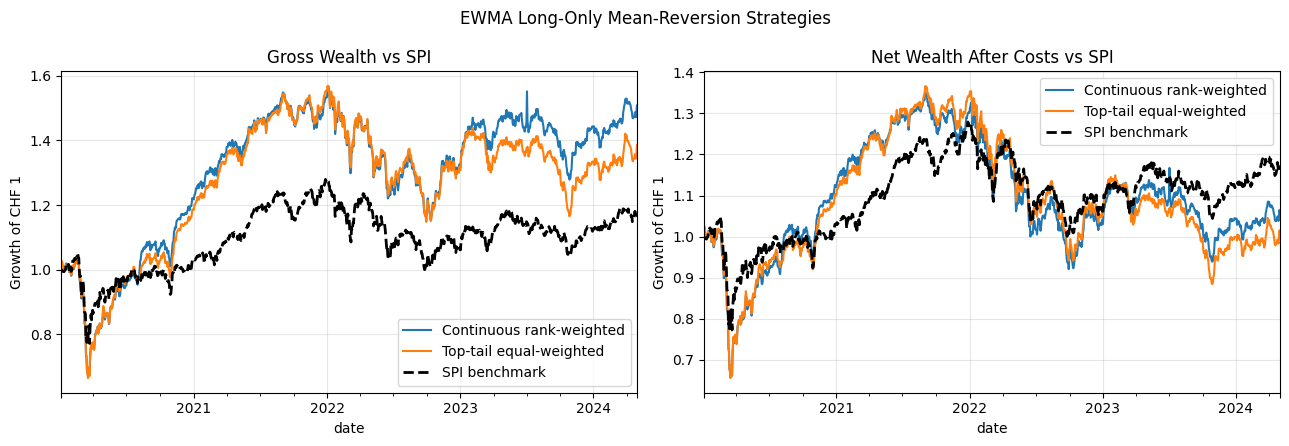

In [14]:
if CONFIG.run_ewma_strategies and strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    benchmark_index = next(iter(strategy_results.values()))["net"].index
    spi_benchmark = spi_returns.reindex(benchmark_index).dropna()

    for name, result in strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("Gross Wealth vs SPI")
    axes[1].set_title("Net Wealth After Costs vs SPI")
    fig.suptitle("EWMA Long-Only Mean-Reversion Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("EWMA wealth plots skipped.")


## Black-Litterman Strategy Backtest

The Black-Litterman portfolios use the same continuous and top-tail signal baskets, but the baskets define views rather than final holdings. The professor optimizer chooses long-only portfolios under the budget, single-name cap and turnover-cost terms.

The view return and view variance are frozen from the 2010-2019 development calibration. They are not re-estimated in the out-of-sample period. In addition to the standard economic and factor metrics, this section reports average signal exposure \(w_t^\top w^{signal}_t\).


In [15]:
def run_bl_strategy(target_weights: pd.DataFrame, view_return: float, view_variance: float) -> Strategy:
    """Run the professor framework with the cost-aware one-sided BL basket view."""
    optimization_builders = {
        "return_series": OptimizationItemBuilder(
            bibfn=bibfn_return_series,
            width=CONFIG.lookback_days,
            weekdays_only=True,
            fillna_value=0,
        ),
        "cap_weights": OptimizationItemBuilder(bibfn=bibfn_cap_weights),
        "signal_weights": OptimizationItemBuilder(
            bibfn=CostAwareOneSidedBasketBlackLitterman.bibfn_signal_weights,
            target_weights=target_weights,
        ),
        "budget": OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
        "box": OptimizationItemBuilder(
            bibfn=bibfn_box_constraints,
            box_type="LongOnly",
            lower=0,
            upper=CONFIG.bl_stock_upper_bound,
        ),
    }
    if CONFIG.bl_use_hard_turnover_cap:
        optimization_builders["turnover"] = OptimizationItemBuilder(
            bibfn=bibfn_turnover_constraint,
            turnover_limit=CONFIG.bl_turnover_limit,
        )

    service = BacktestService(
        data=data,
        selection_item_builders=selection_builders,
        optimization_item_builders=optimization_builders,
        optimization=CostAwareOneSidedBasketBlackLitterman(
            tau=CONFIG.bl_tau,
            risk_aversion=CONFIG.bl_risk_aversion,
            view_return=view_return,
            view_variance=view_variance,
            turnover_penalty=CONFIG.bl_turnover_penalty,
            use_hard_turnover_cap=CONFIG.bl_use_hard_turnover_cap,
            hard_turnover_limit=CONFIG.bl_turnover_limit,
        ),
        rebdates=rebalance_date_strings,
        # quiet=False enables the professor Backtest.run tqdm progress bar.
        quiet=not CONFIG.show_backtest_progress,
    )
    backtest = Backtest()
    backtest.run(service)
    return backtest.strategy


if CONFIG.run_black_litterman_strategies:
    bl_strategies = {
        "Black-Litterman continuous view": run_bl_strategy(
            continuous_target_weights,
            CONFIG.bl_continuous_view_return,
            CONFIG.bl_continuous_view_variance,
        ),
        "Black-Litterman top-tail view": run_bl_strategy(
            tail_target_weights,
            CONFIG.bl_tail_view_return,
            CONFIG.bl_tail_view_variance,
        ),
    }
    bl_strategy_weights = {
        name: strategy.get_weights_df().set_index(pd.to_datetime(strategy.get_weights_df().index))
        for name, strategy in bl_strategies.items()
    }
else:
    bl_strategies, bl_strategy_weights = {}, {}
    print("Black-Litterman backtests skipped by CONFIG.run_black_litterman_strategies=False.")


Running backtest: 100%|##########| 225/225 [18:16<00:00,  4.87s/it, 2024-04-19]


In [16]:
def average_signal_exposure(weights: pd.DataFrame, signal_weights: pd.DataFrame) -> float:
    """Average basket exposure w_t' w_signal,t across rebalance dates."""
    aligned_weights, aligned_signal = weights.align(signal_weights, join="outer", axis=1, fill_value=0.0)
    aligned_signal = aligned_signal.reindex(aligned_weights.index).fillna(0.0)
    return (aligned_weights.fillna(0.0) * aligned_signal).sum(axis=1).mean()


def hard_cap_binding_frequency(result: dict) -> float:
    """Approximate hard-cap binding frequency from realized professor turnover."""
    if not CONFIG.bl_use_hard_turnover_cap:
        return np.nan
    recurring_turnover = result["turnover"].iloc[1:]
    return np.isclose(recurring_turnover, CONFIG.bl_turnover_limit, atol=1e-4).mean()


if CONFIG.run_black_litterman_strategies:
    bl_strategy_results = {
        name: evaluate_strategy(strategy, return_series)
        for name, strategy in bl_strategies.items()
    }

    bl_reference_result = next(iter(bl_strategy_results.values()))
    bl_spi_summary = benchmark_summary(
        "SPI benchmark",
        spi_returns,
        bl_reference_result["net"].index,
        bl_reference_result["turnover"].index,
    )
    bl_performance_table = pd.DataFrame(
        [strategy_summary(name, result, spi_returns) for name, result in bl_strategy_results.items()]
        + [bl_spi_summary]
    )
    display(bl_performance_table.round(4))

    # Factor-model attribution is reported with the same helper used for EWMA strategies.
    bl_factor_diagnostics = factor_diagnostics_table(bl_strategy_results)
    display(bl_factor_diagnostics.round(4))

    bl_signal_baskets = {
        "Black-Litterman continuous view": continuous_target_weights,
        "Black-Litterman top-tail view": tail_target_weights,
    }
    bl_implementation_diagnostics = pd.DataFrame(
        [
            pd.Series(
                {
                    "Average signal exposure": average_signal_exposure(
                        bl_strategy_weights[name],
                        bl_signal_baskets[name],
                    ),
                    "Hard turnover cap binding frequency": hard_cap_binding_frequency(result),
                },
                name=name,
            )
            for name, result in bl_strategy_results.items()
        ]
    )
    display(bl_implementation_diagnostics.round(4))
else:
    bl_strategy_results = {}
    bl_performance_table = pd.DataFrame()
    bl_factor_diagnostics = pd.DataFrame()
    bl_implementation_diagnostics = pd.DataFrame()
    print("Black-Litterman metrics skipped.")


,Geometric annual return,Geometric annual excess return vs SPI,Annual volatility,Sharpe ratio,Skewness,Excess kurtosis,Maximum drawdown,Win rate,Average weekly turnover,Annual TC + 1% fee,Gross bps per trade,Observations
Black-Litterman continuous view,0.0138,-0.0208,0.0825,0.2079,-1.5686,15.9997,-0.2062,0.5536,0.0221,0.0123,286.6039,"1,127.0000"
Black-Litterman top-tail view,0.0189,-0.0158,0.0838,0.2651,-1.3855,15.5155,-0.2058,0.5536,0.0225,0.0123,328.4776,"1,127.0000"
SPI benchmark,0.0346,0.0000,0.1526,0.2997,-0.7894,11.7741,-0.2633,0.5848,NaN,NaN,NaN,"1,127.0000"


,Annualized alpha,Alpha p-value,Information ratio,IR t-statistic,Regression R-squared,Beta SPI,P-value SPI,Beta size,P-value size,Beta value,P-value value,Beta momentum,P-value momentum
Black-Litterman continuous view,-0.0026,0.9208,-0.0540,-0.0994,0.6608,0.4849,0.0000,0.1209,0.0007,0.0411,0.2814,-0.0086,0.6347
Black-Litterman top-tail view,0.0027,0.9236,0.0522,0.0959,0.6355,0.4853,0.0000,0.1296,0.0006,0.0310,0.4310,-0.0064,0.7512


,Average signal exposure,Hard turnover cap binding frequency
Black-Litterman continuous view,0.0073,NaN
Black-Litterman top-tail view,0.0081,NaN


## Black-Litterman Gross And Net Wealth

The BL wealth plots follow the same convention as the EWMA section. Gross wealth isolates the optimized signal tilt before costs; net wealth applies the professor transaction-cost simulation. SPI is the black dashed benchmark path.


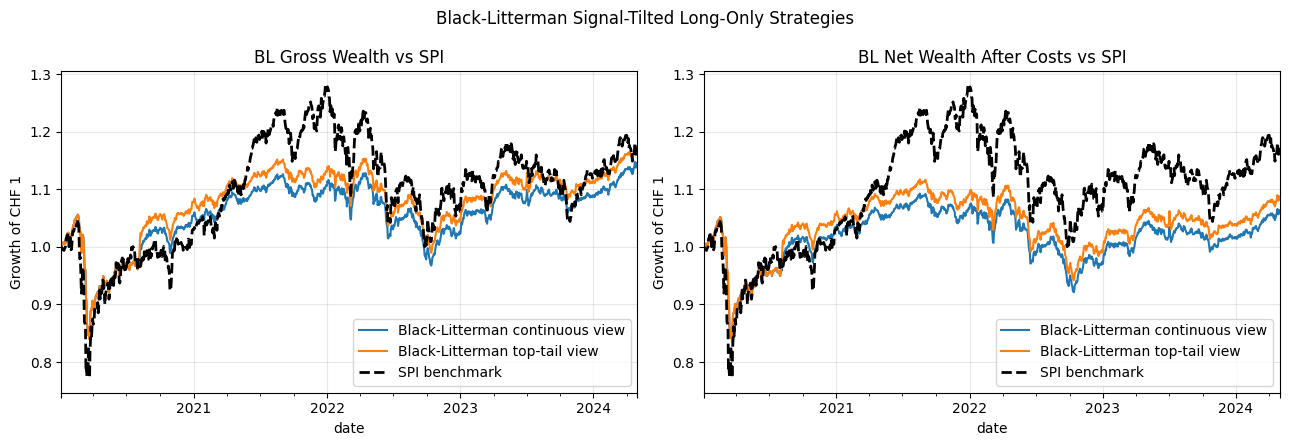

In [17]:
if CONFIG.run_black_litterman_strategies and bl_strategy_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    bl_benchmark_index = next(iter(bl_strategy_results.values()))["net"].index
    bl_spi_benchmark = spi_returns.reindex(bl_benchmark_index).dropna()

    for name, result in bl_strategy_results.items():
        (1 + result["gross"]).cumprod().plot(ax=axes[0], label=name, linewidth=1.5)
        (1 + result["net"]).cumprod().plot(ax=axes[1], label=name, linewidth=1.5)

    for ax in axes:
        (1 + bl_spi_benchmark).cumprod().plot(
            ax=ax,
            label="SPI benchmark",
            color="black",
            linestyle="--",
            linewidth=2,
        )
        ax.set_ylabel("Growth of CHF 1")
        ax.grid(True, alpha=0.3)
        ax.legend()

    axes[0].set_title("BL Gross Wealth vs SPI")
    axes[1].set_title("BL Net Wealth After Costs vs SPI")
    fig.suptitle("Black-Litterman Signal-Tilted Long-Only Strategies")
    fig.tight_layout()
    plt.show()
else:
    print("Black-Litterman wealth plots skipped.")


## Final Conclusion

The out-of-sample results do not support the direct EWMA portfolios as attractive final strategies. The continuous and top-tail EWMA implementations earn annualized net returns of 1.12% and -0.05%, both below the SPI return of 3.46%. Their weekly turnover remains high at 63.5% and 55.4%, so estimated transaction costs and the annual fee absorb most of the gross reversal return. Their Sharpe ratios and drawdowns are also worse than the benchmark.

Black-Litterman provides a more efficient implementation of the same frozen signal. Weekly turnover falls to about 2.2%, annual volatility falls to roughly 8.3%, and maximum drawdown improves to about -20.6%, compared with -26.3% for SPI. The top-tail BL portfolio is the strongest strategy in the notebook, with a 1.89% annualized net return and a 0.265 Sharpe ratio. Nevertheless, it still underperforms SPI, and its factor-adjusted alpha is economically small and statistically insignificant.

The main conclusion is therefore cautious. The volatility-scaled reversal signal contains some gross cross-sectional information, but direct trading is too turnover-intensive. Black-Litterman materially improves implementation efficiency and downside risk, yet it does not produce convincing out-of-sample alpha after costs. The top-tail BL portfolio is the preferred implementation, while the overall evidence does not justify claiming that the strategy dominates the passive SPI benchmark.
